# Decision Tree Learning

Decision trees classify instances by sorting them from root to leaf, where each **internal node** tests an attribute, each **branch** corresponds to an attribute value, and each **leaf** assigns a class label.

**Why Decision Trees?**
- Interpretable (white-box model)
- Handle both categorical and numerical data
- Non-parametric — no assumption about data distribution

---

## 1. Entropy

Entropy measures the **impurity** (uncertainty) of a dataset.

$$H(S) = -\sum_{i=1}^{c} p_i \log_2 p_i$$

where $p_i$ is the proportion of class $i$ in set $S$.

| Scenario | Entropy |
|---|---|
| All same class | 0 (pure) |
| 50-50 split (binary) | 1 (max impurity) |

### Example
Dataset: 9 Yes, 5 No → $H = -\frac{9}{14}\log_2\frac{9}{14} - \frac{5}{14}\log_2\frac{5}{14} \approx 0.940$

Entropy: 0.9403


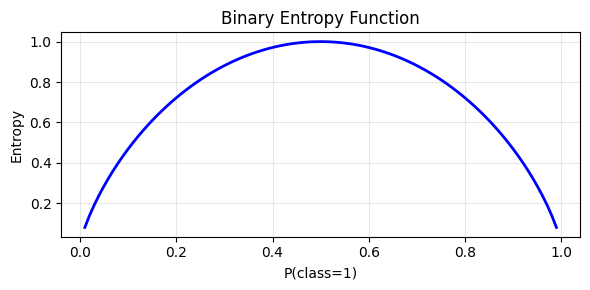

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

def entropy(labels):
    """Calculates entropy of a label array."""
    n = len(labels)
    if n == 0:
        return 0
    counts = np.array(list(Counter(labels).values()))
    probs = counts / n
    return -np.sum(probs * np.log2(probs + 1e-12))

# Example
labels = ['Yes']*9 + ['No']*5
print(f"Entropy: {entropy(labels):.4f}")  # ≈ 0.9403

# Visualize entropy vs probability for binary case
p = np.linspace(0.01, 0.99, 100)
h = -p * np.log2(p) - (1 - p) * np.log2(1 - p)
plt.figure(figsize=(6, 3))
plt.plot(p, h, 'b-', linewidth=2)
plt.xlabel('P(class=1)'); plt.ylabel('Entropy')
plt.title('Binary Entropy Function'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Information Gain

Information gain measures the **reduction in entropy** after splitting on attribute $A$:

$$IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v)$$

**Choose the attribute with the highest information gain** at each node.

> **Bias:** Information gain favors attributes with many values. Gain Ratio (used by C4.5) corrects this:
> $$GainRatio(S, A) = \frac{IG(S, A)}{SplitInfo(A)}$$

In [2]:
def information_gain(data, feature, target):
    """Calculate information gain of splitting data on a feature."""
    parent_entropy = entropy(data[target])
    # Weighted average entropy of children
    values = data[feature].unique()
    weighted_entropy = sum(
        (len(subset := data[data[feature] == v]) / len(data)) * entropy(subset[target])
        for v in values
    )
    return parent_entropy - weighted_entropy

# Classic "Play Tennis" dataset
tennis = pd.DataFrame({
    'Outlook':    ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temp':       ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity':   ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind':       ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayTennis': ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
})

print("Information Gain for each attribute:")
for col in ['Outlook', 'Temp', 'Humidity', 'Wind']:
    ig = information_gain(tennis, col, 'PlayTennis')
    print(f"  {col:10s}: {ig:.4f}")
print("\n→ Outlook has highest IG, so it becomes the root node (ID3).")

Information Gain for each attribute:
  Outlook   : 0.2467
  Temp      : 0.0292
  Humidity  : 0.1518
  Wind      : 0.0481

→ Outlook has highest IG, so it becomes the root node (ID3).


## 3. ID3 Algorithm

**ID3** (Iterative Dichotomiser 3) builds a decision tree top-down using information gain.

```
ID3(S, Attributes):
  1. If all examples in S are same class → return leaf with that class
  2. If Attributes is empty → return leaf with majority class
  3. A* = argmax_{A ∈ Attributes} IG(S, A)
  4. Create node for A*
  5. For each value v of A*:
       - S_v = {s ∈ S | s.A* = v}
       - If S_v is empty → add leaf with majority class of S
       - Else → add subtree ID3(S_v, Attributes - {A*})
```

**Limitations:** Only handles categorical attributes, no pruning, biased toward multi-valued attributes.

In [3]:
class ID3Tree:
    """Simple ID3 decision tree for categorical features."""
    
    def __init__(self):
        self.tree = None
    
    def _build(self, data, features, target):
        labels = data[target]
        # Base cases
        if len(labels.unique()) == 1:
            return labels.iloc[0]
        if len(features) == 0:
            return labels.mode()[0]
        
        # Select best feature
        gains = {f: information_gain(data, f, target) for f in features}
        best = max(gains, key=gains.get)
        
        tree = {best: {}}
        remaining = [f for f in features if f != best]
        
        for val in data[best].unique():
            subset = data[data[best] == val]
            if len(subset) == 0:
                tree[best][val] = labels.mode()[0]
            else:
                tree[best][val] = self._build(subset, remaining, target)
        
        return tree
    
    def fit(self, data, target):
        features = [c for c in data.columns if c != target]
        self.tree = self._build(data, features, target)
        return self
    
    def _predict_one(self, tree, instance):
        if not isinstance(tree, dict):
            return tree
        feature = list(tree.keys())[0]
        value = instance.get(feature)
        subtree = tree[feature].get(value)
        if subtree is None:
            return None  # unseen value
        return self._predict_one(subtree, instance)
    
    def predict(self, data):
        return [self._predict_one(self.tree, row.to_dict()) for _, row in data.iterrows()]

def print_tree(tree, indent='', is_last=True):
    """Pretty-print a nested dict tree with branch characters."""
    if not isinstance(tree, dict):
        print(f' \u2192 \u2718 [{tree}]')
        return
    feature = list(tree.keys())[0]
    branches = list(tree[feature].items())
    for i, (value, subtree) in enumerate(branches):
        last = (i == len(branches) - 1)
        connector = '\u2514\u2500\u2500 ' if last else '\u251c\u2500\u2500 '
        extension = '    ' if last else '\u2502   '
        print(f'{indent}{connector}[{feature} = {value}]', end='')
        if isinstance(subtree, dict):
            print()
            print_tree(subtree, indent + extension, last)
        else:
            print(f' \u2192 \u2718 [{subtree}]')

# Train and test on tennis dataset
id3 = ID3Tree().fit(tennis, 'PlayTennis')

print('\u250c' + '\u2500'*30 + '\u2510')
print('\u2502  Learned ID3 Decision Tree  \u2502')
print('\u2514' + '\u2500'*30 + '\u2518')
print()
print_tree(id3.tree)

preds = id3.predict(tennis)
acc = sum(p == a for p, a in zip(preds, tennis['PlayTennis'])) / len(tennis)
print(f"\nTraining Accuracy: {acc:.2%}")

┌──────────────────────────────┐
│  Learned ID3 Decision Tree  │
└──────────────────────────────┘

├── [Outlook = Sunny]
│   ├── [Humidity = High] → ✘ [No]
│   └── [Humidity = Normal] → ✘ [Yes]
├── [Outlook = Overcast] → ✘ [Yes]
└── [Outlook = Rain]
    ├── [Wind = Weak] → ✘ [Yes]
    └── [Wind = Strong] → ✘ [No]

Training Accuracy: 100.00%


## 4. Gini Index

The Gini index is an alternative impurity measure used by **CART**:

$$Gini(S) = 1 - \sum_{i=1}^{c} p_i^2$$

| Measure | Range | Used By |
|---|---|---|
| Entropy | [0, log₂c] | ID3, C4.5 |
| Gini | [0, 1 - 1/c] | CART |

Both are concave, peak at uniform distribution. In practice, they often select the same splits.

Feature       IG (Entropy)   IG (Gini)
----------------------------------------
Outlook             0.2467      0.1163
Temp                0.0292      0.0187
Humidity            0.1518      0.0918
Wind                0.0481      0.0306


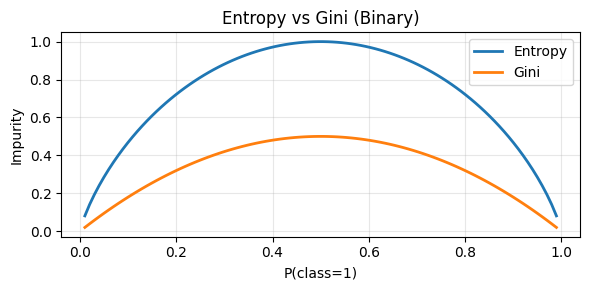

In [4]:
def gini(labels):
    """Calculate Gini impurity."""
    n = len(labels)
    if n == 0:
        return 0
    counts = np.array(list(Counter(labels).values()))
    probs = counts / n
    return 1 - np.sum(probs ** 2)

def gini_gain(data, feature, target):
    """Weighted Gini impurity reduction for a split."""
    parent_gini = gini(data[target])
    weighted = sum(
        (len(subset := data[data[feature] == v]) / len(data)) * gini(subset[target])
        for v in data[feature].unique()
    )
    return parent_gini - weighted

# Compare Entropy vs Gini on tennis dataset
print(f"{'Feature':10s}  {'IG (Entropy)':>14s}  {'IG (Gini)':>10s}")
print('-' * 40)
for col in ['Outlook', 'Temp', 'Humidity', 'Wind']:
    ig_e = information_gain(tennis, col, 'PlayTennis')
    ig_g = gini_gain(tennis, col, 'PlayTennis')
    print(f"{col:10s}  {ig_e:14.4f}  {ig_g:10.4f}")

# Visual comparison
p = np.linspace(0.01, 0.99, 100)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(p, -p*np.log2(p) - (1-p)*np.log2(1-p), label='Entropy', linewidth=2)
ax.plot(p, 2*p*(1-p), label='Gini', linewidth=2)
ax.set_xlabel('P(class=1)'); ax.set_ylabel('Impurity')
ax.set_title('Entropy vs Gini (Binary)'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Handling Continuous (Numerical) Values

For a continuous attribute $A$:
1. **Sort** all values of $A$
2. Consider **candidate thresholds** = midpoints between consecutive distinct values
3. For each threshold $t$, create binary split: $A \leq t$ vs $A > t$
4. Pick the threshold with the **highest information gain**

This is how C4.5 and CART handle continuous features.

In [5]:
def best_threshold(data, feature, target):
    """Find optimal binary split threshold for a continuous feature."""
    sorted_vals = sorted(data[feature].unique())
    best_ig, best_t = -1, None
    
    for i in range(len(sorted_vals) - 1):
        t = (sorted_vals[i] + sorted_vals[i+1]) / 2
        # Create binary split
        left = data[data[feature] <= t][target]
        right = data[data[feature] > t][target]
        n = len(data)
        ig = entropy(data[target]) - (len(left)/n * entropy(left) + len(right)/n * entropy(right))
        if ig > best_ig:
            best_ig, best_t = ig, t
    
    return best_t, best_ig

# Example: Iris dataset with continuous features
from sklearn.datasets import load_iris
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target

print("Best thresholds for Iris features:")
for col in iris.feature_names:
    t, ig = best_threshold(iris_df, col, 'target')
    print(f"  {col:20s}: threshold = {t:.2f}, IG = {ig:.4f}")

Best thresholds for Iris features:
  sepal length (cm)   : threshold = 5.55, IG = 0.5572
  sepal width (cm)    : threshold = 3.35, IG = 0.2831
  petal length (cm)   : threshold = 2.45, IG = 0.9183
  petal width (cm)    : threshold = 0.80, IG = 0.9183


## 6. Handling Missing Values

Common strategies:

| Strategy | Description |
|---|---|
| **Most common value** | Replace missing with mode (categorical) or mean/median (numerical) |
| **Fractional instances** | Send instance down all branches, weighted by proportion (C4.5 approach) |
| **Surrogate splits** | Use correlated features as backup splits (CART approach) |
| **Treat as a value** | Create a separate branch for "missing" |

In [6]:
# Demonstrate handling missing values with sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Create dataset with artificial missing values
np.random.seed(42)
X = iris.data.copy().astype(float)
# Inject 10% missing values
mask = np.random.random(X.shape) < 0.10
X[mask] = np.nan

print(f"Missing values per feature: {np.isnan(X).sum(axis=0)}")

# Strategy 1: Impute with mean
pipe_mean = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('tree', DecisionTreeClassifier(random_state=42))
])

# Strategy 2: Impute with median
pipe_median = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('tree', DecisionTreeClassifier(random_state=42))
])

for name, pipe in [('Mean', pipe_mean), ('Median', pipe_median)]:
    scores = cross_val_score(pipe, X, iris.target, cv=5, scoring='accuracy')
    print(f"{name} imputation → Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Missing values per feature: [23 15 18 16]
Mean imputation → Accuracy: 0.9800 ± 0.0267
Median imputation → Accuracy: 0.9800 ± 0.0267


## 7. Pruning — Reducing Overfitting

Fully grown trees **overfit** training data. Pruning removes branches that provide little predictive power.

### Pre-pruning (Early Stopping)
Stop growing before the tree is fully built:
- `max_depth`: limit tree depth
- `min_samples_split`: minimum samples required to split a node
- `min_samples_leaf`: minimum samples in a leaf

### Post-pruning
Grow full tree, then remove subtrees bottom-up:
- **Reduced Error Pruning**: Replace subtree with leaf if validation accuracy doesn't decrease
- **Cost-Complexity Pruning (CCP)**: Minimize $R_\alpha(T) = R(T) + \alpha|T|$, where $R(T)$ is misclassification rate and $|T|$ is number of leaves. **sklearn uses this with `ccp_alpha`.**

Unpruned: Train=1.000, Test=1.000, Leaves=10
Pre-prune: Train=0.943, Test=1.000, Leaves=5
CCP prune: Train=1.000, Test=1.000, Leaves=10, alpha=0.0000


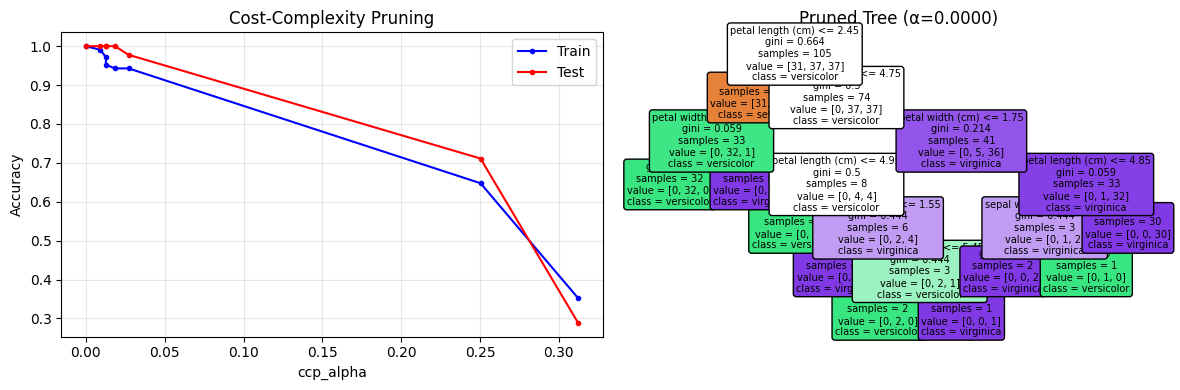

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree

X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Unpruned tree
tree_full = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print(f"Unpruned: Train={tree_full.score(X_train, y_train):.3f}, Test={tree_full.score(X_test, y_test):.3f}, Leaves={tree_full.get_n_leaves()}")

# Pre-pruned tree
tree_pre = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42).fit(X_train, y_train)
print(f"Pre-prune: Train={tree_pre.score(X_train, y_train):.3f}, Test={tree_pre.score(X_test, y_test):.3f}, Leaves={tree_pre.get_n_leaves()}")

# Cost-Complexity Pruning: find optimal alpha
path = tree_full.cost_complexity_pruning_path(X_train, y_train)
alphas, impurities = path.ccp_alphas, path.impurities

train_scores, test_scores = [], []
for a in alphas:
    clf = DecisionTreeClassifier(ccp_alpha=a, random_state=42).fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Alpha vs accuracy
axes[0].plot(alphas, train_scores, 'b-o', ms=3, label='Train')
axes[0].plot(alphas, test_scores, 'r-o', ms=3, label='Test')
axes[0].set_xlabel('ccp_alpha'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Cost-Complexity Pruning'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Best pruned tree
best_alpha = alphas[np.argmax(test_scores)]
tree_ccp = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42).fit(X_train, y_train)
print(f"CCP prune: Train={tree_ccp.score(X_train, y_train):.3f}, Test={tree_ccp.score(X_test, y_test):.3f}, Leaves={tree_ccp.get_n_leaves()}, alpha={best_alpha:.4f}")

# Visualize pruned tree
plot_tree(tree_ccp, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, ax=axes[1], fontsize=7)
axes[1].set_title(f'Pruned Tree (α={best_alpha:.4f})')
plt.tight_layout(); plt.show()

## 8. CART (Classification and Regression Trees)

**CART** differs from ID3/C4.5 in key ways:

| Feature | ID3 | C4.5 | CART |
|---|---|---|---|
| Split criterion | Entropy / IG | Gain Ratio | Gini Index |
| Split type | Multi-way | Multi-way | **Binary only** |
| Feature types | Categorical | Cat. + Continuous | Cat. + Continuous |
| Pruning | None | Error-based | Cost-complexity |
| Regression | No | No | **Yes (MSE)** |
| Missing values | No | Fractional | Surrogate splits |

### CART for Regression
Instead of class labels, CART predicts continuous values by minimizing **MSE** at each split:
$$MSE = \frac{1}{n}\sum(y_i - \bar{y})^2$$

CART (Gini): Train=0.962, Test=0.933
Tree Rules:
|--- x2 <= 0.11
|   |--- x1 <= -0.57
|   |   |--- class: 0
|   |--- x1 >  -0.57
|   |   |--- x2 <= -0.04
|   |   |   |--- x2 <= -0.26
|   |   |   |   |--- class: 1
|   |   |   |--- x2 >  -0.26
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- x2 >  -0.04
|   |   |   |--- x1 <= 1.01
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- x1 >  1.01
|   |   |   |   |--- class: 1
|--- x2 >  0.11
|   |--- x1 <= 1.30
|   |   |--- x2 <= 0.76
|   |   |   |--- x1 <= -0.45
|   |   |   |   |--- class: 0
|   |   |   |--- x1 >  -0.45
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- x2 >  0.76
|   |   |   |--- class: 0
|   |--- x1 >  1.30
|   |   |--- class: 1



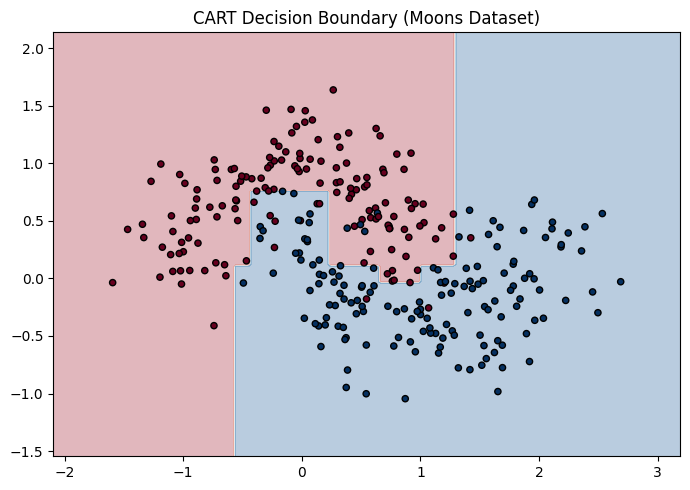

In [8]:
# CART Classification on a synthetic dataset
from sklearn.datasets import make_moons
from sklearn.tree import export_text

X_moon, y_moon = make_moons(n_samples=300, noise=0.25, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_moon, y_moon, test_size=0.3, random_state=42)

cart = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
cart.fit(X_tr, y_tr)

print(f"CART (Gini): Train={cart.score(X_tr, y_tr):.3f}, Test={cart.score(X_te, y_te):.3f}")
print(f"Tree Rules:\n{export_text(cart, feature_names=['x1', 'x2'], max_depth=3)}")

# Decision boundary visualization
fig, ax = plt.subplots(figsize=(7, 5))
xx, yy = np.meshgrid(np.linspace(X_moon[:,0].min()-0.5, X_moon[:,0].max()+0.5, 200),
                      np.linspace(X_moon[:,1].min()-0.5, X_moon[:,1].max()+0.5, 200))
Z = cart.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
ax.scatter(X_moon[:,0], X_moon[:,1], c=y_moon, cmap='RdBu', edgecolors='k', s=20)
ax.set_title('CART Decision Boundary (Moons Dataset)')
plt.tight_layout(); plt.show()

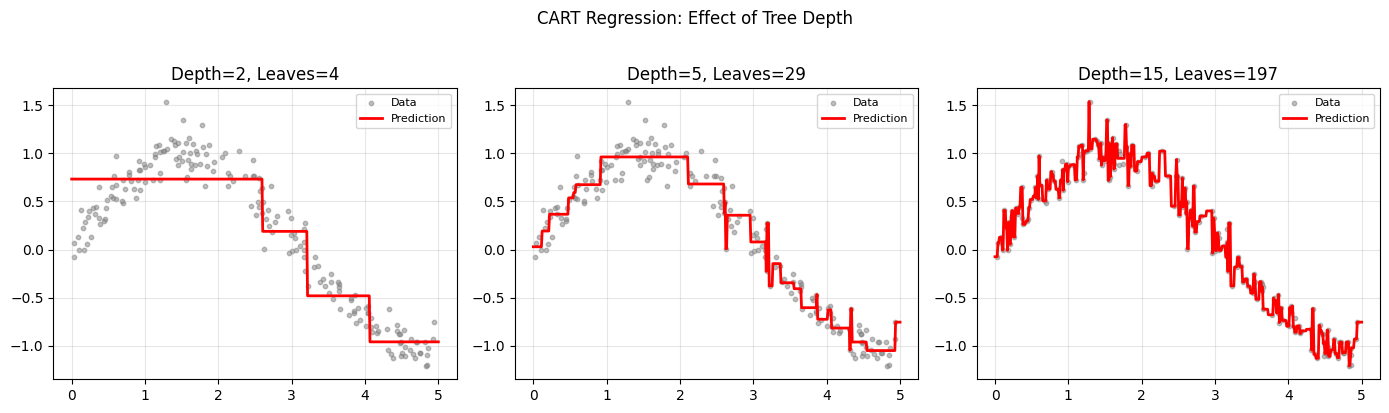

In [9]:
# CART Regression
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
X_reg = np.sort(5 * np.random.rand(200, 1), axis=0)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.15, X_reg.shape[0])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, depth in zip(axes, [2, 5, 15]):
    reg = DecisionTreeRegressor(max_depth=depth, random_state=42).fit(X_reg, y_reg)
    X_plot = np.linspace(0, 5, 500).reshape(-1, 1)
    ax.scatter(X_reg, y_reg, s=10, c='gray', alpha=0.5, label='Data')
    ax.plot(X_plot, reg.predict(X_plot), 'r-', linewidth=2, label='Prediction')
    ax.set_title(f'Depth={depth}, Leaves={reg.get_n_leaves()}')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('CART Regression: Effect of Tree Depth', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

## 9. Other Algorithms

### C4.5 (Quinlan, 1993)
Successor to ID3. Key improvements:
- **Gain Ratio** instead of IG to avoid multi-value bias
- Handles **continuous** attributes via binary thresholds
- Handles **missing values** via fractional weighting
- **Error-based pruning** post-construction

### C5.0
Commercial successor to C4.5 — faster, more memory efficient, supports boosting.

### CHAID (Chi-squared Automatic Interaction Detector)
- Uses **chi-squared test** to determine best splits
- Produces multi-way splits
- Primarily used in marketing/survey analysis

### Comparison Summary

| Algorithm | Year | Criterion | Splits | Pruning | Notes |
|---|---|---|---|---|---|
| ID3 | 1986 | Entropy/IG | Multi-way | None | Categorical only |
| C4.5 | 1993 | Gain Ratio | Multi-way | Error-based | Handles continuous + missing |
| CART | 1984 | Gini/MSE | Binary | Cost-complexity | Classification + Regression |
| CHAID | 1980 | Chi-squared | Multi-way | Pre-prune | Statistical approach |

In [10]:
# Compare criterion choices on a real dataset
from sklearn.datasets import load_wine

wine = load_wine()
X_tr, X_te, y_tr, y_te = train_test_split(wine.data, wine.target, test_size=0.3, random_state=42)

results = []
for criterion in ['gini', 'entropy', 'log_loss']:
    for depth in [None, 3, 5]:
        clf = DecisionTreeClassifier(criterion=criterion, max_depth=depth, random_state=42)
        clf.fit(X_tr, y_tr)
        results.append({
            'Criterion': criterion,
            'Max Depth': depth or 'None',
            'Train Acc': f"{clf.score(X_tr, y_tr):.3f}",
            'Test Acc': f"{clf.score(X_te, y_te):.3f}",
            'Leaves': clf.get_n_leaves()
        })

results_df = pd.DataFrame(results)
print("Decision Tree Comparison on Wine Dataset:")
print(results_df.to_string(index=False))

Decision Tree Comparison on Wine Dataset:
Criterion Max Depth Train Acc Test Acc  Leaves
     gini      None     1.000    0.963       7
     gini         3     0.992    0.963       6
     gini         5     1.000    0.963       7
  entropy      None     1.000    0.852       9
  entropy         3     0.984    0.833       7
  entropy         5     1.000    0.852       9
 log_loss      None     1.000    0.852       9
 log_loss         3     0.984    0.833       7
 log_loss         5     1.000    0.852       9


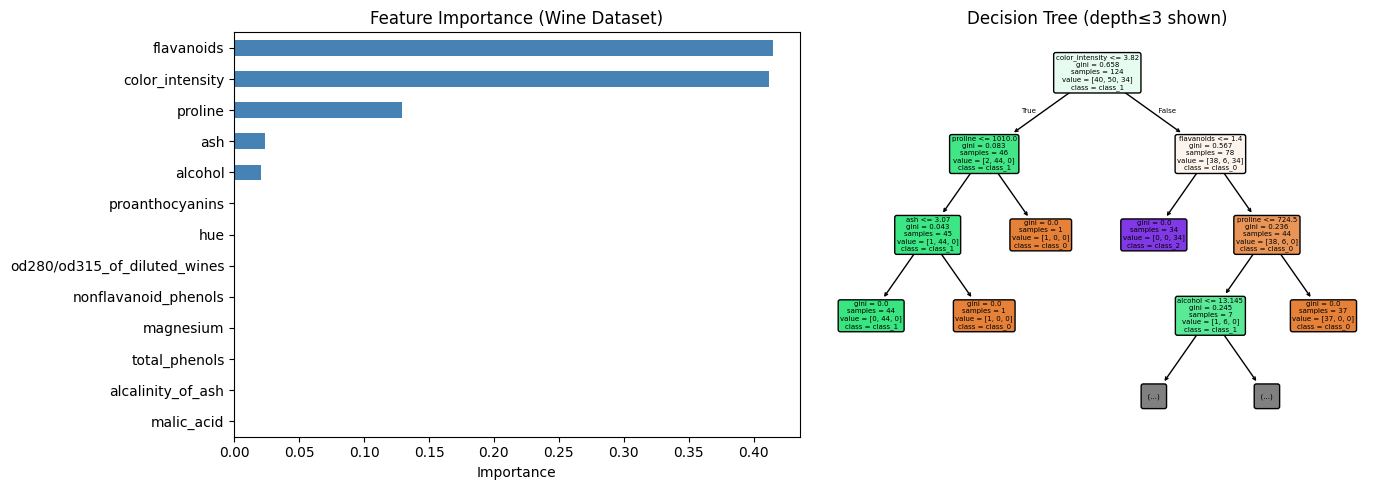


Test Accuracy: 0.963


In [11]:
# Feature importance from CART
best_tree = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
best_tree.fit(X_tr, y_tr)

importance = pd.Series(best_tree.feature_importances_, index=wine.feature_names)
importance = importance.sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance bar chart
importance.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance (Wine Dataset)')
axes[0].set_xlabel('Importance')

# Tree visualization
plot_tree(best_tree, feature_names=wine.feature_names, class_names=wine.target_names,
          filled=True, rounded=True, ax=axes[1], fontsize=5, max_depth=3)
axes[1].set_title('Decision Tree (depth≤3 shown)')
plt.tight_layout(); plt.show()

print(f"\nTest Accuracy: {best_tree.score(X_te, y_te):.3f}")

## 10. Summary

| Concept | Key Takeaway |
|---|---|
| **Entropy** | Measures disorder; 0 = pure, max = uniform distribution |
| **Information Gain** | Entropy reduction from splitting; used to select attributes |
| **Gini Index** | Alternative impurity; computationally simpler than entropy |
| **ID3** | Greedy top-down, entropy-based, categorical only |
| **CART** | Binary splits, Gini/MSE, supports regression |
| **Continuous values** | Binary threshold search on sorted feature values |
| **Missing values** | Imputation, fractional instances, or surrogate splits |
| **Pruning** | Essential to prevent overfitting; CCP is the standard approach |